# Stock Price Forecasting with LSTM

This notebook demonstrates how to predict stock prices using a Long Short-Term Memory (LSTM) network, a type of recurrent neural network ideal for time series data.

In [19]:
%pip install yfinance -q

Note: you may need to restart the kernel to use updated packages.


In [20]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense, LSTM
from sklearn.preprocessing import MinMaxScaler

## Data Inspection

Inspect the structure, types, and missing values in the dataset.

In [21]:
data = pd.read_csv("symbols_valid_meta.csv")

# Step: Quick preview
data.head()

,Nasdaq Traded,Symbol,Security Name,Listing Exchange,Market Category,ETF,Round Lot Size,Test Issue,Financial Status,CQS Symbol,NASDAQ Symbol,NextShares
0,Y,A,"Agilent Technologies, Inc. Common Stock",N,,N,100.0,N,NaN,A,A,N
1,Y,AA,Alcoa Corporation Common Stock,N,,N,100.0,N,NaN,AA,AA,N
2,Y,AAAU,Perth Mint Physical Gold ETF,P,,Y,100.0,N,NaN,AAAU,AAAU,N
3,Y,AACG,ATA Creativity Global - American Depositary Sh...,Q,G,N,100.0,N,N,NaN,AACG,N
4,Y,AADR,AdvisorShares Dorsey Wright ADR ETF,P,,Y,100.0,N,NaN,AADR,AADR,N


In [22]:
# Inspect data structure and types
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8049 entries, 0 to 8048
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Nasdaq Traded     8049 non-null   object 
 1   Symbol            8049 non-null   object 
 2   Security Name     8049 non-null   object 
 3   Listing Exchange  8049 non-null   object 
 4   Market Category   8049 non-null   object 
 5   ETF               8049 non-null   object 
 6   Round Lot Size    8049 non-null   float64
 7   Test Issue        8049 non-null   object 
 8   Financial Status  3383 non-null   object 
 9   CQS Symbol        4666 non-null   object 
 10  NASDAQ Symbol     8049 non-null   object 
 11  NextShares        8049 non-null   object 
dtypes: float64(1), object(11)
memory usage: 754.7+ KB


In [23]:
# Check for missing values
missing_summary = data.isnull().sum()
print(missing_summary[missing_summary > 0])

Financial Status    4666
CQS Symbol          3383
dtype: int64


In [24]:
# Pick a stock symbol
symbol = 'AAPL'

# Download historical data
data = yf.download(symbol, start='2015-01-01', end='2024-01-01')
data = data[['Close']]
data.dropna(inplace=True)
data.head()


[*********************100%***********************]  1 of 1 completed



Price,Close
Ticker,AAPL
Date,
2015-01-02,24.320433
2015-01-05,23.635281
2015-01-06,23.637512
2015-01-07,23.968958
2015-01-08,24.889896


## Basic Statistics and Distribution

Explore the numerical columns and visualize the distribution of key variables.

In [25]:
# Describe numerical columns
data.describe()

Price,Close
Ticker,AAPL
count,2264.000000
mean,81.673040
std,56.182341
min,20.674534
25%,32.926905
50%,51.395996
75%,139.493004
max,196.927658


## Data Preprocessing

Handle missing or extreme values and prepare the data for forecasting.

In [26]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

def create_sequences(data, seq_length=60):
    X, y = [], []
    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i])
        y.append(data[i])
    return np.array(X), np.array(y)

seq_length = 60
X, y = create_sequences(scaled_data, seq_length)

X = X.reshape((X.shape[0], X.shape[1], 1))

In [27]:
# Build the LSTM model
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(X.shape[1], 1)),
    LSTM(50),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(X, y, epochs=10, batch_size=32)


c:\Users\Christian\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step - loss: 0.0420
Epoch 2/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step - loss: 0.0420
Epoch 2/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - loss: 6.3843e-04
Epoch 3/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - loss: 6.3843e-04
Epoch 3/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - loss: 5.0335e-04
Epoch 4/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - loss: 5.0335e-04
Epoch 4/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 5.2496e-04
Epoch 5/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 5.2496e-04
Epoch 5/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 5.0208e-04
Epoch 6/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 5.0208e-04
Epoch 6/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 4.4140e-04
Epoch 7/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 4.4140e-04
Epoch 7/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 3.8730e-04
Epoch 8/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 3.8730e-04
Epoch 8/10
69/69 ━━━━━━━━━

## Forecasting Preparation

Convert the data to a time series format and resample it for analysis.

69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step


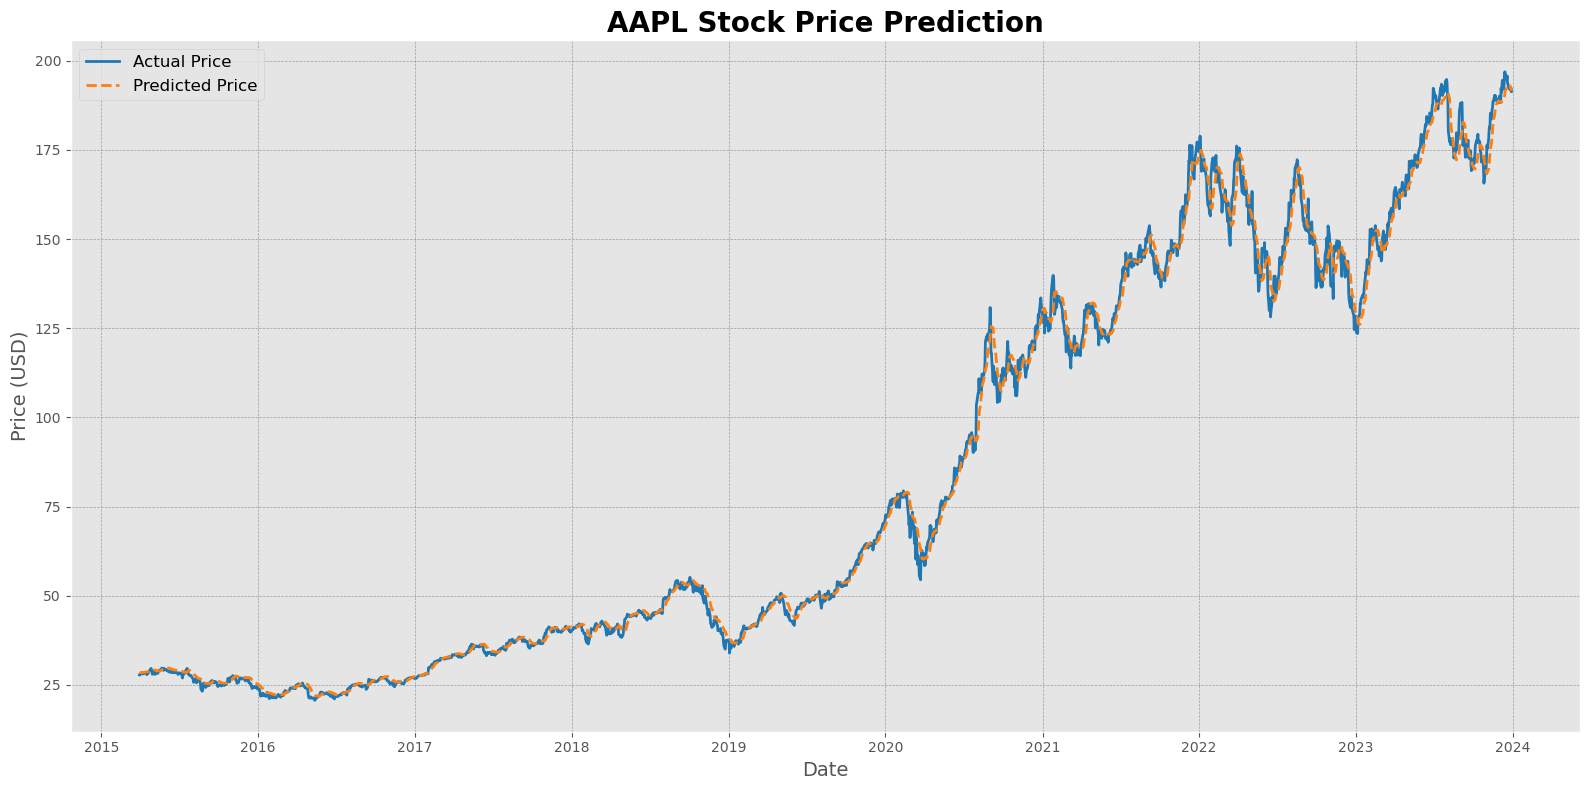

In [29]:
# Make predictions
predicted = model.predict(X)
predicted_prices = scaler.inverse_transform(predicted)
actual_prices = scaler.inverse_transform(y.reshape(-1, 1))

# Plot results with enhanced styling and meaningful x-axis labels
plt.style.use('ggplot')  # Use a valid Matplotlib style
plt.figure(figsize=(16, 8))
plt.plot(data.index[-len(actual_prices):], actual_prices, label='Actual Price', color='#1f77b4', linewidth=2)
plt.plot(data.index[-len(predicted_prices):], predicted_prices, label='Predicted Price', color='#ff7f0e', linestyle='--', linewidth=2)
plt.title(f'{symbol} Stock Price Prediction', fontsize=20, fontweight='bold')
plt.xlabel('Date', fontsize=14)
plt.ylabel('Price (USD)', fontsize=14)
plt.legend(fontsize=12, loc='upper left')
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.savefig('stock_price_prediction.png', dpi=300, bbox_inches='tight')  # Save for LinkedIn
plt.show()